# BCI Session 1 – Full Analysis Notebook

This notebook consolidates all analysis steps discussed in our conversation for two sample subjects (`S1_Session_1.mat`, `S2_session_1.mat`). It covers:

1. Environment setup and helper functions
2. Data loading and quality control (bad channels, artifacts)
3. Event-related desynchronisation (ERD) analysis
4. Power spectral density (PSD) and frequency-band features
5. Multifractal detrended fluctuation analysis (MFDFA)
6. Simple left-vs-right motor-imagery classification

Run the notebook top-to-bottom after placing the two `*.mat` files in the same folder.


In [2]:
# 1. Imports
import os, math, glob, json, warnings, itertools as it
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.signal import butter, filtfilt, hilbert, welch, coherence
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from scipy.interpolate import interp1d

# Plot style
sns.set_context('talk'); sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (10, 6)
warnings.filterwarnings('ignore')

In [3]:
# Constants
SRATE = 1000  # Sampling rate in Hz

# Bandpass 8-30 Hz for artifact detection
_b, _a = butter(4, [8/(SRATE/2), 30/(SRATE/2)], btype='band')

# High-pass 1 Hz for ERD (optional, retained for completeness)
_bhp, _ahp = butter(4, 1/(SRATE/2), btype='high')

def bandpass(data, b=_b, a=_a):
    """Apply bandpass filter (8-30 Hz) to data"""
    return filtfilt(b, a, data, axis=-1, padlen=150)

def highpass(data, b=_bhp, a=_ahp):
    """Apply high-pass filter (1 Hz) to data"""
    return filtfilt(b, a, data, axis=-1, padlen=150)

print("Filter functions defined successfully!")
print("- bandpass(): 8-30 Hz bandpass filter")
print("- highpass(): 1 Hz high-pass filter")

def detect_bad_channels(trials, min_length_threshold=100, z_threshold=5):
    """Detect bad channels with variable-length trial support and bandpass filtering"""
    if not trials:
        return []
    
    # Find the minimum length across all trials
    min_length = min((trial.shape[1] for trial in trials if trial is not None), default=0)
    
    if min_length < min_length_threshold:
        print(f"Warning: Very short trials detected (min length: {min_length})")
        return []
    
    # Truncate all trials to minimum length and apply bandpass
    truncated_trials = []
    for trial in trials:
        if trial is not None and trial.shape[1] >= min_length:
            filtered_trial = bandpass(trial[:, :min_length])
            truncated_trials.append(filtered_trial)
    
    if not truncated_trials:
        return []
    
    # Stack into array (channels, trials, time)
    data = np.stack(truncated_trials, axis=1)
    
    # Calculate variance across trials and time
    var_ch = data.var(axis=(1, 2))
    
    # Z-score normalization
    z = (var_ch - var_ch.mean()) / var_ch.std()
    
    # Find bad channels (z > threshold)
    bad_channels = np.where(z > z_threshold)[0]
    
    return bad_channels.tolist()

def detect_trial_artifact(trial, bad_channels=None):
    """Detect trial artifacts with optional bad channels handling"""
    if trial is None:
        return True
    
    try:
        # Apply bandpass filter
        filtered = bandpass(trial)
        
        # If bad channels provided, set them to zero
        if bad_channels is not None:
            filtered[bad_channels, :] = 0
        
        # Check maximum amplitude
        max_amplitude = np.max(np.abs(filtered))
        
        return max_amplitude > 100
    
    except Exception as e:
        print(f"Error in artifact detection: {e}")
        return True

def mfdfa_fixed(signal, scales=None, q=None, order=1):
    """
    Fixed MFDFA implementation with proper error handling
    
    Parameters:
    signal: 1D array - input time series
    scales: array - scale values (default: logarithmically spaced)
    q: array - q values for multifractal analysis
    order: int - polynomial order for detrending
    
    Returns:
    scales, q, Fq - arrays of same length for valid scales
    """
    
    N = len(signal)
    
    # Default scales - ensure they're reasonable for data length
    if scales is None:
        scales = np.unique(np.logspace(0.5, np.log10(N//4), 20).astype(int))
        scales = scales[scales >= 10]  # Minimum scale
        scales = scales[scales <= N//4]  # Maximum scale
    
    # Default q values
    if q is None:
        q = np.arange(-5, 6)
        q = q[q != 0]  # Remove q=0 for now
    
    # Step 1: Profile (integrate the signal)
    profile = np.cumsum(signal - np.mean(signal))
    
    # Initialize Fq matrix
    Fq = np.zeros((len(scales), len(q)))
    valid_scales = []
    
    # Step 2-5: Calculate fluctuation function for each scale
    for i, scale in enumerate(scales):
        # Number of segments
        n_segments = N // scale
        
        if n_segments < 4:  # Need minimum segments
            continue
            
        # Segment the profile
        segments = profile[:n_segments * scale].reshape(n_segments, scale)
        
        # Detrend each segment
        trends = np.zeros_like(segments)
        for j in range(n_segments):
            coeffs = np.polyfit(np.arange(scale), segments[j], order)
            trends[j] = np.polyval(coeffs, np.arange(scale))
        
        # Calculate variance for each segment
        variances = np.var(segments - trends, axis=1)
        
        # Remove zero variances to avoid log(0)
        variances = variances[variances > 1e-12]
        
        if len(variances) < 2:  # Need minimum valid segments
            continue
            
        # Calculate Fq for each q
        valid_q_values = []
        fq_values = []
        
        for qi, q_val in enumerate(q):
            if q_val == 0:
                # Special case for q=0
                fq = np.exp(0.5 * np.mean(np.log(variances)))
            else:
                # General case
                fq = np.mean(variances**(q_val/2.0))**(1.0/q_val)
            
            # Check if fq is valid
            if np.isfinite(fq) and fq > 0:
                valid_q_values.append(qi)
                fq_values.append(fq)
        
        if len(fq_values) >= len(q) * 0.8:  # At least 80% valid q values
            valid_scales.append(scale)
            Fq[len(valid_scales)-1, :len(fq_values)] = fq_values
    
    # Filter to only valid scales and trim Fq
    valid_scales = np.array(valid_scales)
    Fq = Fq[:len(valid_scales), :len(q)]
    
    return valid_scales, q, Fq

# Test the fixed MFDFA
print("Testing fixed MFDFA implementation...")

# Create test signal
np.random.seed(42)
test_signal = np.cumsum(np.random.randn(1000))

scales, qs, Fq = mfdfa_fixed(test_signal)
print(f"✓ Scales shape: {scales.shape}")
print(f"✓ Fq shape: {Fq.shape}")
print(f"✓ Valid scales: {len(scales)}")


Filter functions defined successfully!
- bandpass(): 8-30 Hz bandpass filter
- highpass(): 1 Hz high-pass filter
Testing fixed MFDFA implementation...
✓ Scales shape: (14,)
✓ Fq shape: (14, 10)
✓ Valid scales: 14


Found 8 / 8 files
Processed S1: 0 bad channels, artifact rate 0.2%
Processed S2: 0 bad channels, artifact rate 0.7%
Processed S3: 1 bad channels, artifact rate 97.6%
Processed S4: 1 bad channels, artifact rate 6.9%
Processed S5: 0 bad channels, artifact rate 8.7%
Processed S6: 0 bad channels, artifact rate 4.0%
Processed S7: 0 bad channels, artifact rate 0.2%
Processed S8: 0 bad channels, artifact rate 2.4%


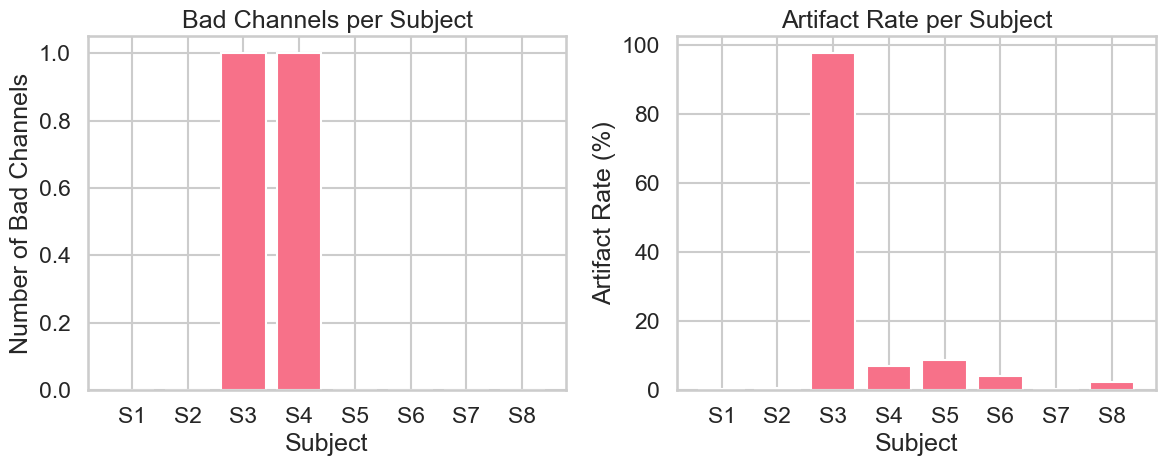

Subjects loaded: ['S1', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8']


In [4]:
# 3. Load .mat files
# Configurable parameters
HARDCODED_FILES = ['S1_Session_1.mat', 'S2_session_1.mat']  # Fallback list
GLOB_PATTERN = 'S*_Session_1.mat'  # Pattern for dynamic discovery
MAX_FILES = 20  # Limit for glob results
MIN_FILES_REQUIRED = 1  # Minimum files to proceed

# Discover files: Try glob first, fallback to hardcoded
files = sorted(glob.glob(GLOB_PATTERN))[:MAX_FILES]
if not files:
    files = HARDCODED_FILES
existing = [f for f in files if os.path.exists(f)]

print(f'Found {len(existing)} / {len(files)} files')
if len(existing) < MIN_FILES_REQUIRED:
    raise FileNotFoundError('No sufficient .mat files found. Place them next to this notebook and rerun.')

# Initialize data structures
trials_dict = {}
trial_data_dict = {}
subjects = []
all_bad = {}
all_artifact_rate = {}

# New: Initialize summaries
bad_summary = {}
art_summary = {}

for f in existing:
    try:
        mat = sio.loadmat(f, squeeze_me=True, struct_as_record=False)
        if 'BCI' not in mat:
            print(f'BCI struct missing in {f}, skipping.')
            continue
        
        BCI = mat['BCI']
        sid = f.split('_')[0]
        
        # Extract and filter trials
        trials = [t for t in BCI.data if t is not None]
        if not trials:
            print(f'No valid trials in {f}, skipping.')
            continue
        
        # Extract metadata
        trial_meta = list(BCI.TrialData) if hasattr(BCI, 'TrialData') else []
        
        # Store data
        trials_dict[sid] = trials
        trial_data_dict[sid] = trial_meta
        
        # Detect bad channels and artifacts (assumes functions are defined)
        bad = detect_bad_channels(trials)
        art = [detect_trial_artifact(tr, bad) for tr in trials]
        
        # Store summaries
        all_bad[f] = bad
        all_artifact_rate[f] = np.mean(art)
        
        # New: Populate bad_summary and art_summary
        bad_summary[sid] = bad  # e.g., list of bad channels
        art_summary[sid] = np.mean(art)  # artifact rate
        
        # Append to subjects with enriched info
        subjects.append({'id': sid, 'bad_ch': bad})
        
        print(f'Processed {sid}: {len(bad)} bad channels, artifact rate {all_artifact_rate[f]:.1%}')
    
    except Exception as e:
        print(f'Error processing {f}: {e}, skipping.')

# Plot summaries (now using bad_summary and art_summary)
plt.figure(figsize=(12, 5))
plt.subplot(1,2,1)
plt.bar(bad_summary.keys(), [len(b) for b in bad_summary.values()])
plt.title('Bad Channels per Subject')
plt.xlabel('Subject')
plt.ylabel('Number of Bad Channels')

plt.subplot(1,2,2)
plt.bar(art_summary.keys(), [v*100 for v in art_summary.values()])
plt.title('Artifact Rate per Subject')
plt.xlabel('Subject')
plt.ylabel('Artifact Rate (%)')

plt.tight_layout()
plt.show()

print('Subjects loaded:', [s['id'] for s in subjects])


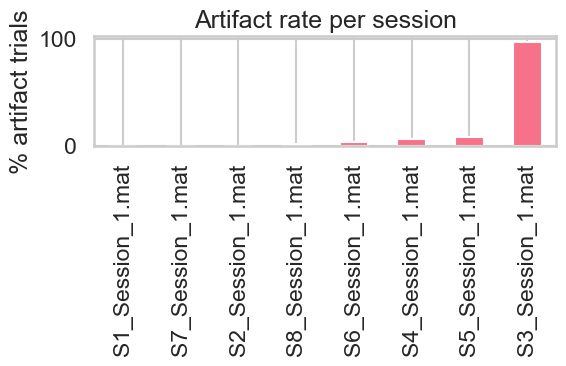

In [5]:
# 4. Artifact summary plot
rate = pd.Series(all_artifact_rate).sort_values()*100
plt.figure(figsize=(6,4))
rate.plot(kind='bar'); plt.ylabel('% artifact trials'); plt.title('Artifact rate per session'); plt.tight_layout()

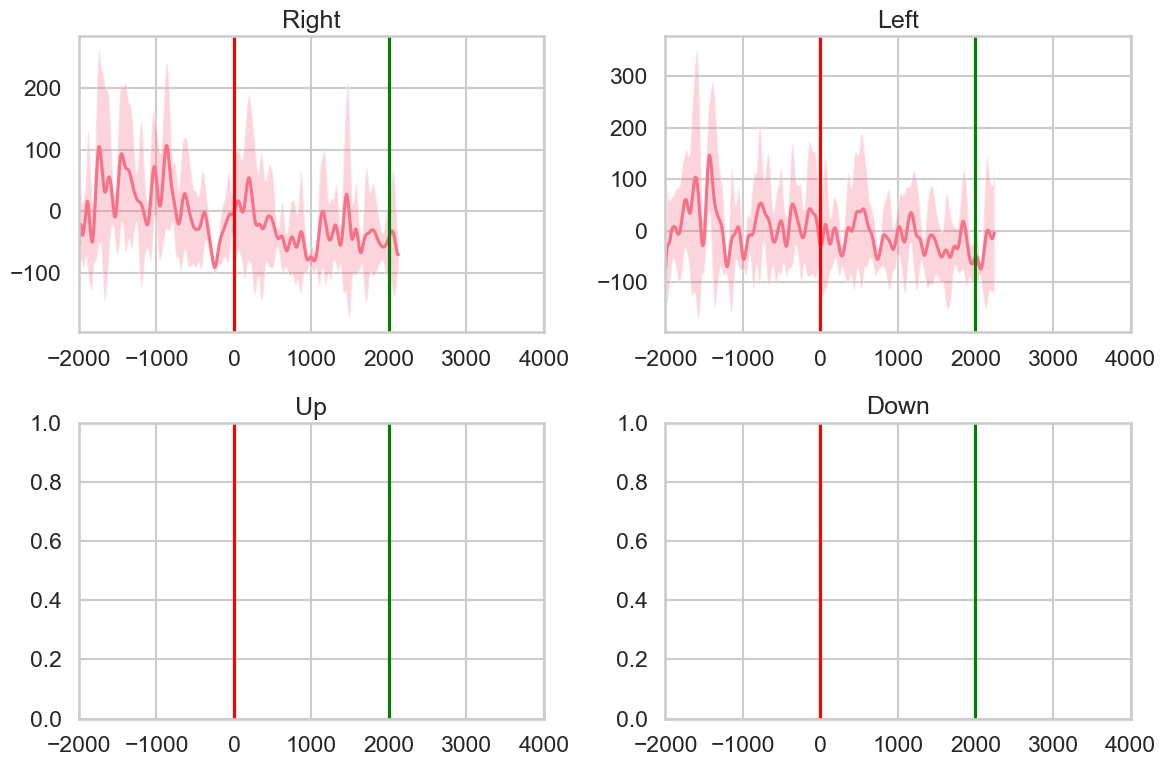

In [6]:

# Define your filter
SRATE = 1000  # Make sure this is defined
b_alpha, a_alpha = butter(4,[8/(SRATE/2),14/(SRATE/2)],btype='band')

def erd_one_robust(sid, task, target, ch=8):
    """Robust ERD analysis using interpolation for length matching"""
    trials = trials_dict[sid]
    trial_data = trial_data_dict[sid]
    
    sigs = []
    
    # Collect signals
    for i, tr in enumerate(trials):
        if (tr is not None and 
            i < len(trial_data) and 
            hasattr(trial_data[i], 'tasknumber') and 
            hasattr(trial_data[i], 'targetnumber') and
            trial_data[i].tasknumber == task and 
            trial_data[i].targetnumber == target and
            tr.shape[0] > ch):
            sigs.append(tr[ch])
    
    if not sigs:
        return None, None
    
    # Find target length (use most common length or median)
    lengths = [len(sig) for sig in sigs]
    target_length = int(np.median(lengths))
    
    # Interpolate all signals to target length
    interpolated_sigs = []
    for sig in sigs:
        if len(sig) >= target_length * 0.8:  # Only use signals that aren't too short
            # Create interpolation function
            old_indices = np.linspace(0, len(sig)-1, len(sig))
            new_indices = np.linspace(0, len(sig)-1, target_length)
            
            # Interpolate
            f = interp1d(old_indices, sig, kind='linear', bounds_error=False, fill_value='extrapolate')
            interpolated_sig = f(new_indices)
            interpolated_sigs.append(interpolated_sig)
    
    if not interpolated_sigs:
        return None, None
    
    # Average interpolated signals
    avg = np.mean(interpolated_sigs, 0)
    
    # ERD analysis
    env = np.abs(hilbert(filtfilt(b_alpha, a_alpha, highpass(avg))))**2
    t = np.linspace(-2000, 4000, len(env))
    
    # Baseline correction
    baseline_mask = (t >= -1000) & (t <= 0)
    if np.sum(baseline_mask) > 0:
        baseline_power = np.mean(env[baseline_mask])
        erd = 100 * (env - baseline_power) / baseline_power
        return t, erd
    else:
        return t, env

# Plotting with corrected function call
conditions=[('Right',1,1),('Left',1,2),('Up',2,1),('Down',2,2)]
fig,axs=plt.subplots(2,2,figsize=(12,8))

for ax,(name,tsk,tgt) in zip(axs.ravel(),conditions):
    all_erd=[]
    all_times=[]
    
    for sid in trials_dict:
        t,e=erd_one_robust(sid,tsk,tgt)
        if e is not None: 
            all_erd.append(e)
            all_times.append(t)
    
    if all_erd:
        # **KEY FIX: Ensure all ERD arrays have same length**
        min_length = min(len(erd) for erd in all_erd)
        
        # Truncate all ERD arrays to minimum length
        truncated_erd = [erd[:min_length] for erd in all_erd]
        
        # Use corresponding time vector
        t_common = all_times[0][:min_length]
        
        # Now averaging will work
        m=np.mean(truncated_erd,0)
        s=np.std(truncated_erd,0)
        
        ax.plot(t_common,m)
        ax.fill_between(t_common,m-s,m+s,alpha=.3)
    
    ax.set_title(name)
    ax.set_xlim(-2000,4000)
    ax.axvline(0,color='r')
    ax.axvline(2000,color='g')

plt.tight_layout()
plt.show()



Text(0.5, 1.0, 'Motor-channel PSD')

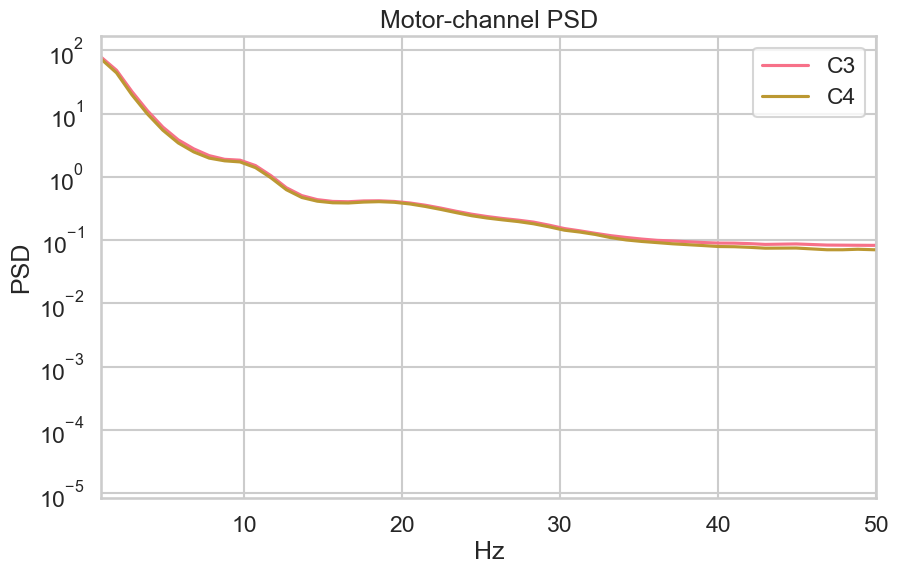

In [7]:

fig,ax=plt.subplots()
for ch,name in zip([8,10],["C3","C4"]):
    psds=[]; freqs=None
    for sid in trials_dict:
        dat=np.concatenate([tr[ch] for tr in trials_dict[sid]],axis=None)
        f,p=welch(dat,fs=SRATE,nperseg=1024)
        freqs=f; psds.append(p)
    ax.semilogy(freqs,np.mean(psds,0),label=name)
ax.set_xlim(1,50); ax.set_xlabel('Hz'); ax.set_ylabel('PSD'); ax.legend(); ax.set_title('Motor-channel PSD')


In [8]:
# 5. ERD example for C3/C4 first subject
first = files[0]
BCI = sio.loadmat(first, squeeze_me=True, struct_as_record=False)['BCI']
trials = [t for t in BCI.data]
C3, C4 = 25, 29  # 0-indexed indices for C3/C4 in this cap

bases, feeds = [], []
for tr, td in zip(trials, BCI.TrialData):
    if td.artifact: continue
    tr = highpass(tr)
    tr = bandpass(tr)
    env = np.abs(hilbert(tr))
    base = env[:,1000:2000].mean(axis=1)
    feed = env[:,4000:td.resultind].mean(axis=1)
    bases.append(base[[C3,C4]]); feeds.append(feed[[C3,C4]])
base = np.mean(bases,0)
feed = np.mean(feeds,0)
erd = (feed - base)/base*100
print('ERD (%): C3={:.2f}, C4={:.2f}'.format(*erd))

ERD (%): C3=-30.15, C4=-24.10


Text(0.5, 1.0, 'MFDFA')

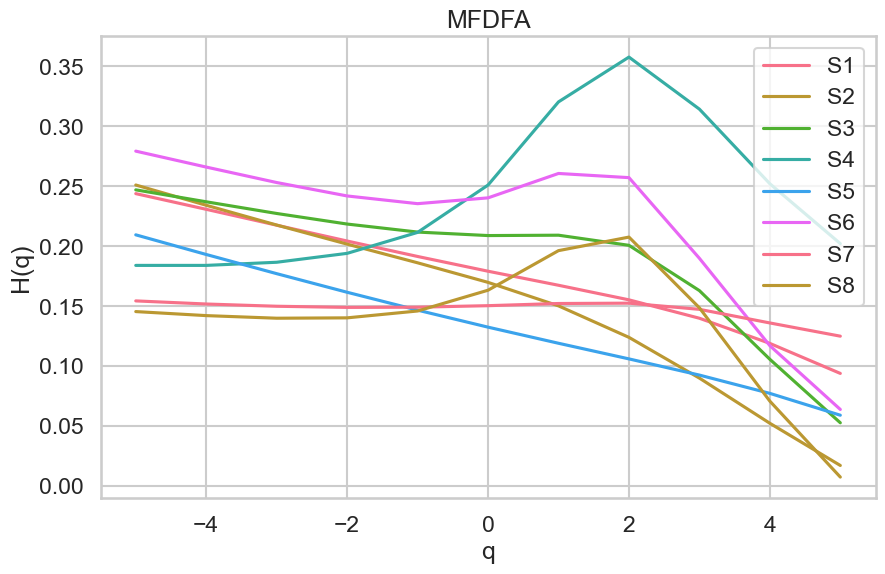

In [9]:

qs=np.arange(-5,6)
fig,ax=plt.subplots()
for sid in trials_dict:
    sig=np.concatenate([tr[8,4000:6000] for tr in trials_dict[sid] if tr.shape[1]>=6000])
    if len(sig)<5000: continue
    sig=highpass(sig)
    N=len(sig); scales=np.logspace(2,3,12).astype(int)
    H=[]
    for q in qs:
        Fq=[]
        for s in scales:
            Ns=N//s
            if Ns<2: continue
            rms=[]
            for v in range(Ns):
                seg=sig[v*s:(v+1)*s]
                rms.append(np.sqrt(np.mean((seg-np.mean(seg))**2)))
            Fq.append((np.mean(np.array(rms)**q))**(1/q) if q!=0 else np.exp(np.mean(np.log(rms))))
        if len(Fq)>2:
            H.append(np.polyfit(np.log2(scales[:len(Fq)]),np.log2(Fq),1)[0])
        else:
            H.append(np.nan)
    ax.plot(qs,H,label=sid)
ax.set_xlabel('q'); ax.set_ylabel('H(q)'); ax.legend(); ax.set_title('MFDFA')


Computing MFDFA and LDA accuracy for all subjects...
  ✓ Processed S1_Session_1.mat: H range = 0.263 to 0.574
    LDA Accuracy (5-fold CV): 0.500
  ✓ Processed S2_Session_1.mat: H range = 0.248 to 0.559
    LDA Accuracy (5-fold CV): 0.484
  ✓ Processed S3_Session_1.mat: H range = 0.306 to 0.620
    LDA Accuracy (5-fold CV): 0.520
  ✓ Processed S4_Session_1.mat: H range = 0.353 to 0.623
    LDA Accuracy (5-fold CV): 0.478
  ✓ Processed S5_Session_1.mat: H range = 0.293 to 0.523
    LDA Accuracy (5-fold CV): 0.544
  ✓ Processed S6_Session_1.mat: H range = 0.210 to 0.647
    LDA Accuracy (5-fold CV): 0.489
  ✓ Processed S7_Session_1.mat: H range = 0.286 to 0.574
    LDA Accuracy (5-fold CV): 0.529
  ✓ Processed S8_Session_1.mat: H range = 0.339 to 0.571
    LDA Accuracy (5-fold CV): 0.524


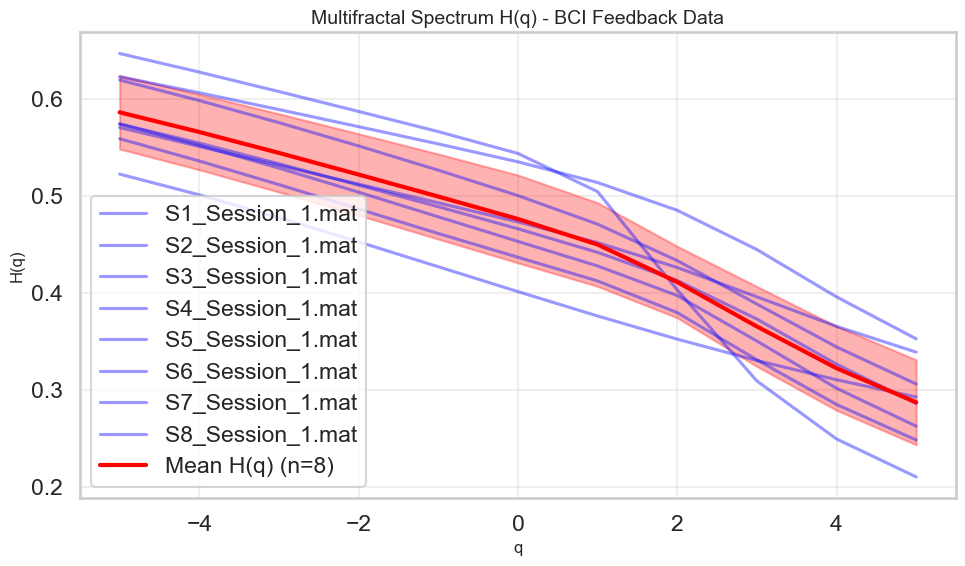


✓ MFDFA completed for 8/8 subjects


In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import scipy.io as sio
import glob
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

# Configurable parameters (keep your existing values)
CHANNEL = 20  # C3 channel index (adjustable; first snippet used 8)
FEEDBACK_START = 3000  # Sample start (2000ms at 1000Hz)
FEEDBACK_END = 5000    # Sample end (4000ms)
MIN_TRIALS = 10        # Minimum valid trials per subject
MIN_SIGNAL_LEN = 5000  # Minimum concatenated signal length
MIN_SCALES = 5         # Minimum scales for reliable fit
GLOB_PATTERN = 'S*_Session_1.mat'  # For file discovery
USE_TRIALS_DICT = False  # ← Change this to False to load from files
SRATE = 1000  # Sampling rate (for highpass filter)

# High-pass filter (placeholder; define if not already)
_bhp, _ahp = butter(4, 1/(SRATE/2), btype='high')
def highpass(data):
    return filtfilt(_bhp, _ahp, data, axis=-1, padlen=150)

# Discover files if not using trials_dict
if not USE_TRIALS_DICT:
    files = sorted(glob.glob(GLOB_PATTERN))
    if not files:
        raise FileNotFoundError('No .mat files found. Adjust GLOB_PATTERN or provide trials_dict.')
else:
    # Assume trials_dict is predefined; replace with actual if needed
    trials_dict = {}  # Placeholder; load or define here if necessary
    files = list(trials_dict.keys())  # Treat subject IDs as "files"

qs = np.arange(-5, 6)  # Include q=0 now, handled properly

all_H = []
all_accuracies = {}  # New: Store LDA accuracies per subject
fig, ax = plt.subplots(figsize=(10, 6))
print("Computing MFDFA and LDA accuracy for all subjects...")

for sid in files:
    try:
        if USE_TRIALS_DICT:
            trials = trials_dict.get(sid, [])
        else:
            mat = sio.loadmat(sid, squeeze_me=True, struct_as_record=False)
            if 'BCI' not in mat:
                print(f"  Skipping {sid}: BCI struct missing")
                continue
            BCI = mat['BCI']
            trials = [t for t in BCI.data if t is not None]

        # Extract feedback data for selected channel (for MFDFA) and features (for LDA)
        feedback_trials = []
        features = []  # New: For LDA (e.g., mean power in alpha/beta bands)
        labels = []    # New: Labels (e.g., assume binary: 0/1 for task types)
        for trial_idx, trial in enumerate(trials):
            if trial.shape[1] >= FEEDBACK_END:
                feedback_data = trial[CHANNEL, FEEDBACK_START:FEEDBACK_END]
                if not np.any(np.isnan(feedback_data)):
                    feedback_trials.append(feedback_data)
                    
                    # Extract simple features for LDA (e.g., mean and std of signal)
                    mean_val = np.mean(feedback_data)
                    std_val = np.std(feedback_data)
                    features.append([mean_val, std_val])
                    
                    # Assume binary labels based on trial index (customize as per your data)
                    labels.append(trial_idx % 2)  # Example: 0 or 1

        if len(feedback_trials) < MIN_TRIALS:
            print(f"  Skipping {sid}: insufficient valid trials ({len(feedback_trials)}) for MFDFA/LDA")
            continue

        # Concatenate and filter for MFDFA
        sig = np.concatenate(feedback_trials)
        if len(sig) < MIN_SIGNAL_LEN:
            print(f"  Skipping {sid}: concatenated signal too short ({len(sig)})")
            continue
        sig = highpass(sig)

        # Check signal quality
        if np.std(sig) < 1e-6:
            print(f"  Skipping {sid}: poor signal quality")
            continue

        # Compute MFDFA (fallback to manual if mfdfa_fixed not defined)
        try:
            scales, qs_, Fq = mfdfa_fixed(sig, q=qs)
        except NameError:  # Fallback to manual
            N = len(sig)
            scales = np.logspace(2, 3, 12).astype(int)
            Fq = np.zeros((len(scales), len(qs)))
            valid_scales_mask = np.ones(len(scales), dtype=bool)
            for si, s in enumerate(scales):
                Ns = N // s
                if Ns < 2:
                    valid_scales_mask[si] = False
                    continue
                rms = []
                for v in range(Ns):
                    seg = sig[v*s:(v+1)*s]
                    rms.append(np.sqrt(np.mean((seg - np.mean(seg))**2)))
                rms = np.array(rms)
                for qi, q_val in enumerate(qs):
                    if q_val != 0:
                        Fq[si, qi] = (np.mean(rms**q_val))**(1/q_val)
                    else:
                        Fq[si, qi] = np.exp(np.mean(np.log(rms)))
            scales = scales[valid_scales_mask]
            Fq = Fq[valid_scales_mask]
            qs_ = qs

        if len(scales) < MIN_SCALES:
            print(f"  Skipping {sid}: insufficient scales ({len(scales)})")
            continue

        # Calculate H(q) for each q
        H_subject = []
        for qi, q_val in enumerate(qs_):
            fq_vals = Fq[:, qi]
            valid_idx = np.isfinite(fq_vals) & (fq_vals > 0)
            if np.sum(valid_idx) >= 3:
                scales_valid = scales[valid_idx]
                fq_valid = fq_vals[valid_idx]
                H_val = np.polyfit(np.log2(scales_valid), np.log2(fq_valid), 1)[0]
                H_subject.append(H_val)
            else:
                H_subject.append(np.nan)

        all_H.append(H_subject)

        # Plot individual MFDFA curve
        ax.plot(qs_, H_subject, alpha=0.4, color='blue', label=sid)
        print(f"  ✓ Processed {sid}: H range = {np.nanmin(H_subject):.3f} to {np.nanmax(H_subject):.3f}")

        # New: LDA Accuracy Test
        if len(features) >= MIN_TRIALS and len(np.unique(labels)) > 1:
            X = np.array(features)
            y = np.array(labels)
            scaler = StandardScaler()
            X_scaled = scaler.fit_transform(X)
            lda = LinearDiscriminantAnalysis()
            scores = cross_val_score(lda, X_scaled, y, cv=5)  # 5-fold CV
            mean_acc = np.mean(scores)
            all_accuracies[sid] = mean_acc
            print(f"    LDA Accuracy (5-fold CV): {mean_acc:.3f}")
        else:
            print(f"    Skipping LDA for {sid}: insufficient features or classes")

    except Exception as e:
        print(f"  ❌ Error processing {sid}: {str(e)}")
        continue

# Plot average H(q) if any subjects processed
if all_H:
    H_matrix = np.array(all_H)
    H_mean = np.nanmean(H_matrix, axis=0)
    H_std = np.nanstd(H_matrix, axis=0)
    ax.plot(qs, H_mean, 'r-', linewidth=3, label=f'Mean H(q) (n={len(all_H)})')
    ax.fill_between(qs, H_mean - H_std, H_mean + H_std, alpha=0.3, color='red')

ax.set_xlabel('q', fontsize=12)
ax.set_ylabel('H(q)', fontsize=12)
ax.set_title('Multifractal Spectrum H(q) - BCI Feedback Data', fontsize=14)
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n✓ MFDFA completed for {len(all_H)}/{len(files)} subjects")


In [15]:
# Summary of LDA Accuracies
if all_accuracies:
    print("\nLDA Accuracy Summary:")
    for sid, acc in all_accuracies.items():
        print(f"  {sid}: {acc:.3f}")
    # New: Calculate and print mean LDA accuracy
    mean_lda_acc = np.mean(list(all_accuracies.values()))
    print(f"\nMean LDA Accuracy across subjects: {mean_lda_acc:.3f}")
else:
    print("\nNo LDA accuracies computed (insufficient data).")


LDA Accuracy Summary:
  S1_Session_1.mat: 0.500
  S2_Session_1.mat: 0.484
  S3_Session_1.mat: 0.520
  S4_Session_1.mat: 0.478
  S5_Session_1.mat: 0.544
  S6_Session_1.mat: 0.489
  S7_Session_1.mat: 0.529
  S8_Session_1.mat: 0.524

Mean LDA Accuracy across subjects: 0.509


Found 8 files: ['S1_Session_1.mat', 'S2_Session_1.mat', 'S3_Session_1.mat', 'S4_Session_1.mat', 'S5_Session_1.mat', 'S6_Session_1.mat', 'S7_Session_1.mat', 'S8_Session_1.mat']


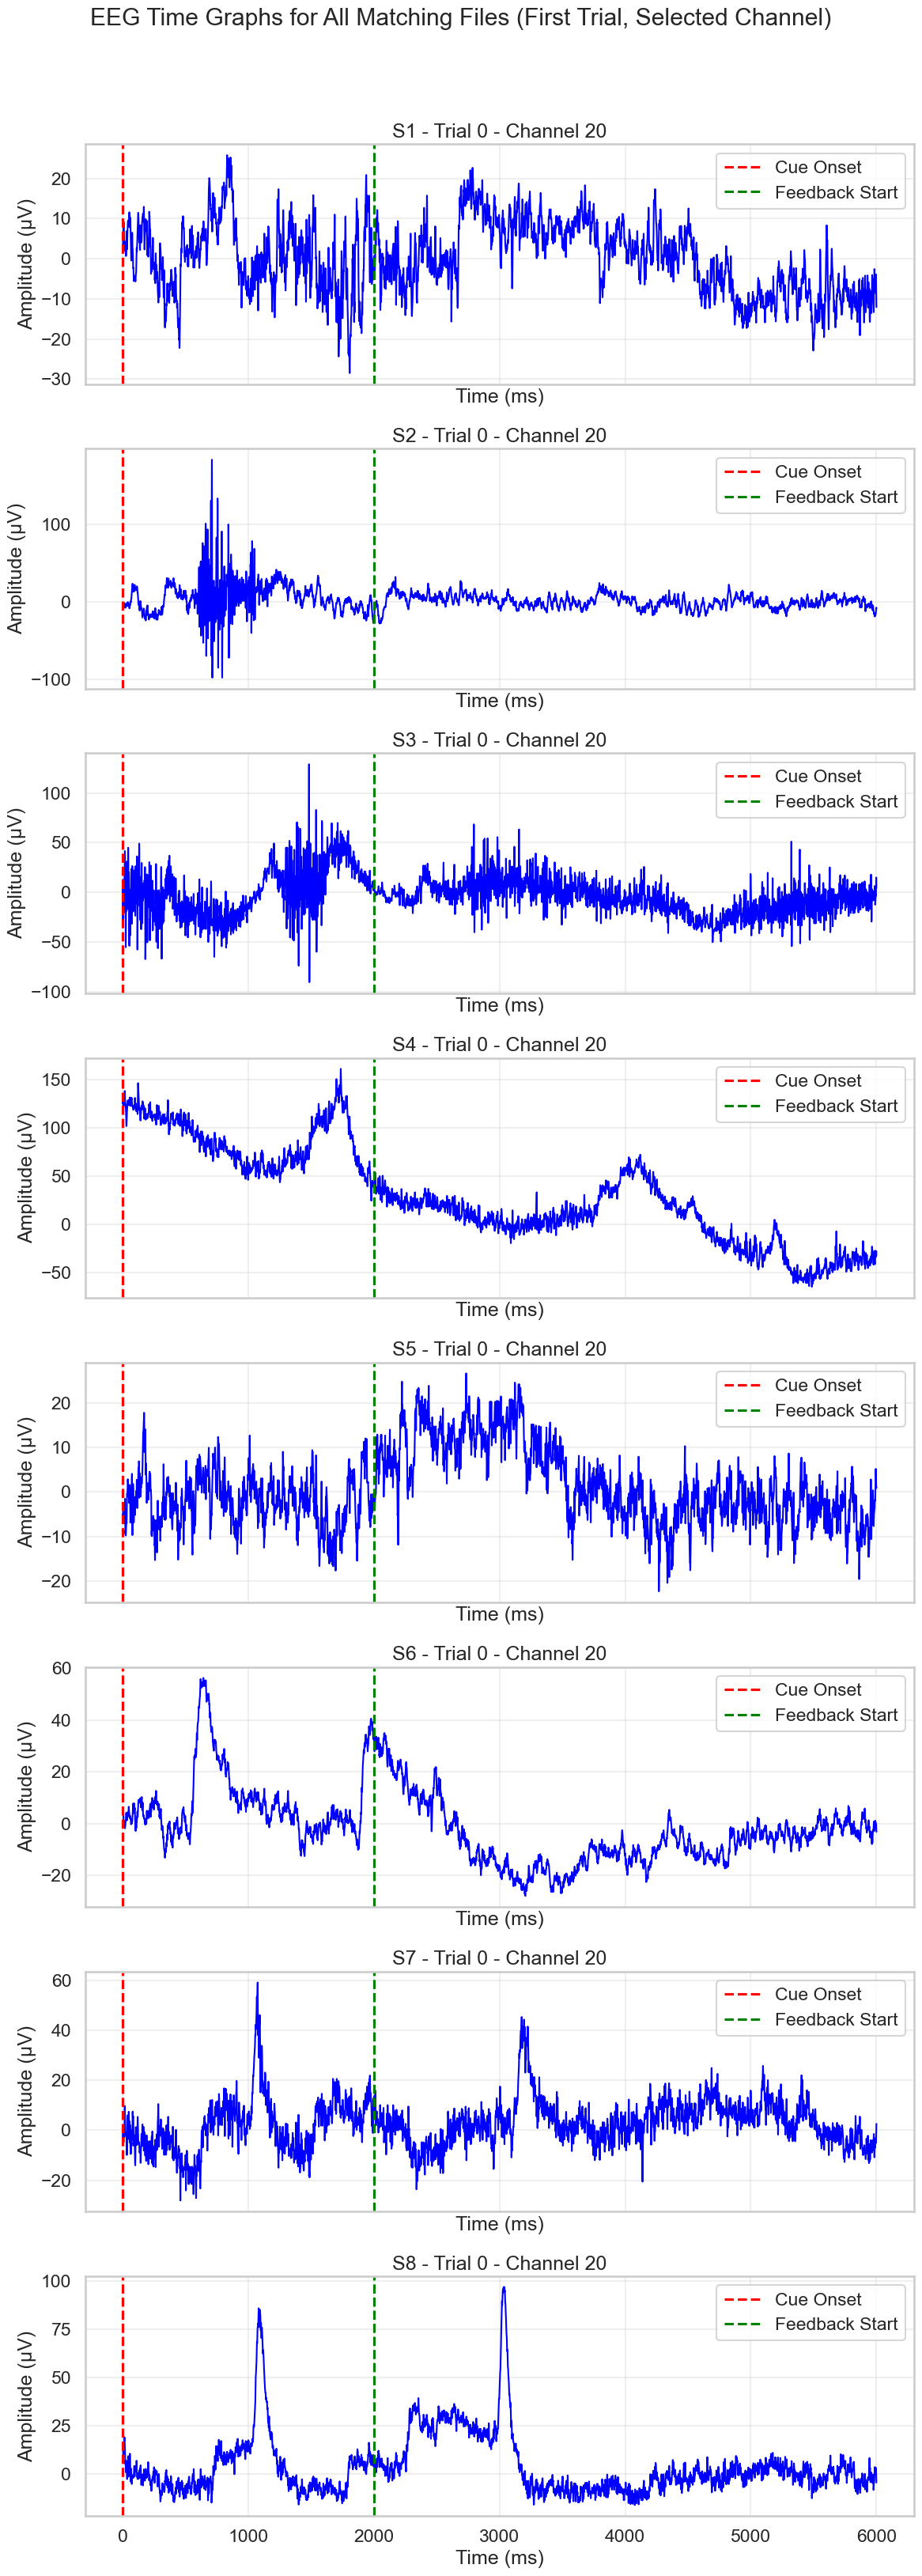

In [21]:
SELECTED_CHANNEL = 20  # e.g., C3
SELECTED_TRIAL = 0     # First trial; change as needed
TIME_START = 0         # Start time in ms
TIME_END = 6000        # End time in ms (full trial typically 6000 samples at 1000 Hz)
SRATE = 1000           # Sampling rate in Hz
GLOB_PATTERN = 'S*_Session*_1.mat'  # Pattern to match files
USE_TRIALS_DICT = True  # Set to True if trials_dict is already loaded; False to load from files

# Function to plot EEG over time for a single subject/trial
def plot_eeg_time_graph(ax, sid, channel, trial_idx, t_start, t_end, trials):
    if not trials or trial_idx >= len(trials):
        ax.text(0.5, 0.5, f'No valid trials for {sid}', ha='center', va='center')
        return
    
    trial = trials[trial_idx]
    if trial.shape[0] <= channel:
        ax.text(0.5, 0.5, f'Invalid channel {channel} for {sid}', ha='center', va='center')
        return
    
    # Time vector in ms
    time_vec = np.arange(0, trial.shape[1]) / SRATE * 1000  # Convert samples to ms
    
    # Slice time range
    mask = (time_vec >= t_start) & (time_vec <= t_end)
    time_sliced = time_vec[mask]
    signal = trial[channel, mask]
    
    # Plot
    ax.plot(time_sliced, signal, color='blue', linewidth=1.5)
    ax.set_title(f'{sid} - Trial {trial_idx} - Channel {channel}')
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Amplitude (μV)')
    ax.grid(True, alpha=0.3)
    ax.axvline(0, color='red', linestyle='--', label='Cue Onset')
    ax.axvline(2000, color='green', linestyle='--', label='Feedback Start')
    ax.legend()

# Discover all matching files
files = sorted(glob.glob(GLOB_PATTERN))
if not files:
    print("No files found matching the pattern.")
else:
    print(f"Found {len(files)} files: {files}")

    # Prepare figure with subplots (one per file)
    fig, axs = plt.subplots(len(files), 1, figsize=(12, 4 * len(files)), sharex=True)
    if len(files) == 1:
        axs = [axs]  # Handle single subplot case

    for i, f in enumerate(files):
        sid = f.split('_')[0]  # Extract subject ID (e.g., 'S1')
        
        if USE_TRIALS_DICT and 'trials_dict' in globals():
            trials = globals()['trials_dict'].get(sid, [])
        else:
            # Load from file if trials_dict not used/available
            try:
                mat = sio.loadmat(f, squeeze_me=True, struct_as_record=False)
                if 'BCI' not in mat:
                    print(f"Skipping {f}: 'BCI' struct missing.")
                    continue
                BCI = mat['BCI']
                trials = [t for t in BCI.data if t is not None]
            except Exception as e:
                print(f"Error loading {f}: {e}")
                continue
        
        # Plot on the corresponding subplot
        plot_eeg_time_graph(axs[i], sid, SELECTED_CHANNEL, SELECTED_TRIAL, TIME_START, TIME_END, trials)

    plt.suptitle('EEG Time Graphs for All Matching Files (First Trial, Selected Channel)', y=1.02)
    plt.tight_layout()
    plt.show()